
The Challenge
The sinking of the Titanic is one of the most infamous shipwrecks in history.

[link to Kaggle](https://www.kaggle.com/code/alexisbcook/titanic-tutorial)

On April 15, 1912, during her maiden voyage, the widely considered “unsinkable” RMS Titanic sank after colliding with an iceberg. Unfortunately, there weren’t enough lifeboats for everyone onboard, resulting in the death of 1502 out of 2224 passengers and crew.

While there was some element of luck involved in surviving, it seems some groups of people were more likely to survive than others.

In this challenge, we ask you to build a predictive model that answers the question: “what sorts of people were more likely to survive?” using passenger data (ie name, age, gender, socio-economic class, etc).

Recommended Tutorial
We highly recommend Alexis Cook’s Titanic Tutorial that walks you through making your very first submission step by step and this starter notebook to get started.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import os
for dirname, _, filenames in os.walk('kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

kaggle/input\titanic\gender_submission.csv
kaggle/input\titanic\test.csv
kaggle/input\titanic\train.csv


This shows us where the competition data is stored, so that we can load the files into the notebook. We'll do that next.

Load the data

The second code cell in your notebook now appears below the three lines of output with the file locations.

In [2]:
train_data = pd.read_csv("kaggle/input/titanic/train.csv")
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
train_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
train_data.shape

(891, 12)

Let's read test file

In [6]:
test_data = pd.read_csv("kaggle/input/titanic/test.csv")
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [7]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [8]:
test_data.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [9]:
test_data.shape

(418, 11)

In [10]:
gender_data = pd.read_csv("kaggle/input/titanic/gender_submission.csv")
gender_data.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


Let's clean data

Starting with removing duplicates

In [11]:
print(f"Duplicate rows: {train_data.duplicated().sum()}")

Duplicate rows: 0


There're no duplicates, that's good

Let's check missing values

In [12]:
print(train_data.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


so we have some empty lines. i feel like we could delete them, but here probably better to replace with some value

In [13]:
women = train_data.loc[train_data.Sex == 'female']["Survived"]
rate_women = sum(women)/len(women)
print("% of women who survived:", rate_women)


% of women who survived: 0.7420382165605095


In [14]:
man = train_data.loc[train_data.Sex == 'male']["Survived"]
rate_man = sum(man)/len(man)
print("% of women who survived:", rate_man)

% of women who survived: 0.18890814558058924


it's significantly less then woman. Bad for them

In [20]:
print("% of people who survived:", train_data['Survived'].mean())


% of people who survived: 0.3838383838383838


Maybe hight class survived more

<Axes: xlabel='Pclass'>

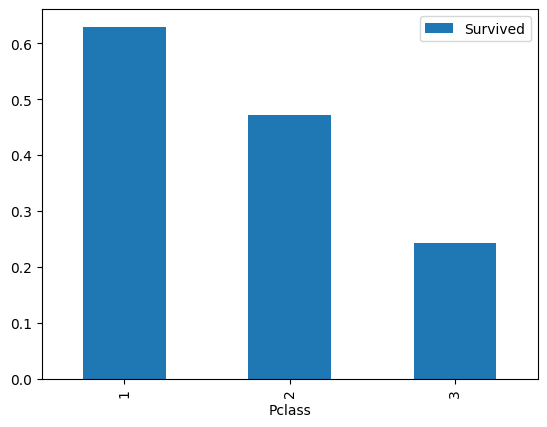

In [23]:
class_pivot = train_data.pivot_table(index="Pclass", values="Survived")
class_pivot.plot.bar()

It's seems so

Maybe younger ones survived more

<Axes: ylabel='Frequency'>

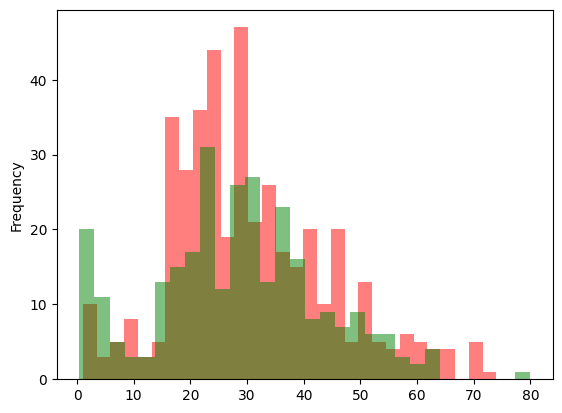

In [25]:
survived = train_data[train_data["Survived"] == 1]
died = train_data[train_data["Survived"] == 0]
died["Age"].plot.hist(alpha=0.5, color='red', bins=30, label='Died')
survived["Age"].plot.hist(alpha=0.5, color='green', bins=30, label='Survived')

It's not so obvious plot maybe we can make based on relation of one to another

C:\Users\tobok\AppData\Local\Temp\ipykernel_47256\1074104411.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_rate = train_data.groupby('AgeGroup')['Survived'].apply(lambda x: (x.mean()) * 100)


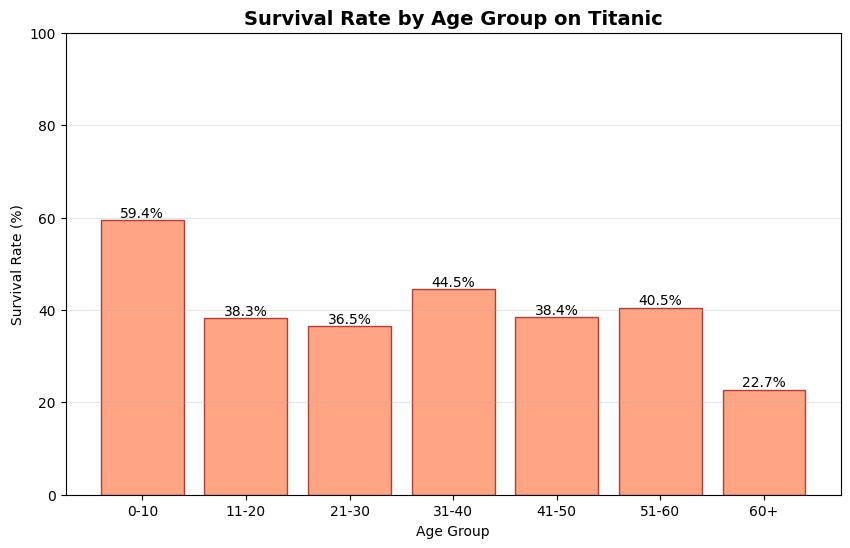

In [40]:
train_data['AgeGroup'] = pd.cut(train_data['Age'], 
                           bins=[0, 10, 20, 30, 40, 50, 60, 100],
                           labels=['0-10', '11-20', '21-30', '31-40', 
                                  '41-50', '51-60', '60+'])


survival_rate = train_data.groupby('AgeGroup')['Survived'].apply(lambda x: (x.mean()) * 100)

# Simple bar plot
plt.figure(figsize=(10, 6))
bars = plt.bar(survival_rate.index, survival_rate.values, 
               color='coral', edgecolor='darkred', alpha=0.7)

# Add percentage labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%', ha='center', va='bottom')

plt.title('Survival Rate by Age Group on Titanic', fontsize=14, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Survival Rate (%)')
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)

plt.show()

i am not sure if it's that much correlated